# Data Analysis

Before developing regression models, a thorough exploratory analysis of the preprocessed dataset is carried out. The goals are to validate the data quality, understand the distribution and relationships of each variable, and identify any structural issues (redundant features, scale mismatches, or temporal and spatial biases) that should be addressed before model training.

The analysis is structured in five parts:

1. **Basic structure** — shape, variable types, descriptive statistics, and missing values.
2. **Univariate distributions** — per-variable histograms and transformation study for the target variable.
3. **Multivariate analysis** — inter-variable correlation, redundancy in the brightness-temperature block.
4. **Machine learning considerations** — a closer look at variable scale and a PCA-based dimensionality assessment.
4. **Spatial and temporal structure** — how the target variable and record density vary across space and time.

## 0. Setup

### 0.1 Library loading

Standard scientific Python stack (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`) plus `cartopy` for geographic projections and `sklearn` for scaling and PCA.

In [44]:
import locale
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

from matplotlib.colors import PowerNorm
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer

locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')

'en_US.UTF-8'

### 0.2 Data loading

All 726 daily Parquet files produced by the preprocessing notebook are read into a single DataFrame using `pd.read_parquet` with directory-level loading. The resulting dataset covers the land surface globally for 2017–2018 at 0.25° resolution (descending passes only).

In [45]:
df = pd.read_parquet("data/datasets")

### 0.3 Constants

`REF_YEAR` is a fixed leap year used to map day-of-year integers to calendar dates for axis labelling, without altering the underlying data.

In [46]:
REF_YEAR = 2000  # leap year — safely handles doy 366 if present

## 1. Basic Structure

The following cells confirm the shape of the dataset, verify that all variables are present with the expected types, and flag any anomalies in the summary statistics or missing values before proceeding to deeper analysis.

### 1.1 Shape

In [26]:
df.shape

(26482762, 49)

The dataset contains **25.3 million rows** and **49 columns**, representing individual valid land pixels across 726 daily Parquet files. Each row corresponds to one (latitude, longitude, day) observation that passed all quality filters applied during preprocessing.

### 1.2 Variables

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26482762 entries, 0 to 26482761
Data columns (total 49 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   latitude_grid                float32
 1   longitude_grid               float32
 2   surtep_ERA5                  float32
 3   fwns                         float32
 4   Tmn                          float32
 5   PWV                          float32
 6   VOD                          float32
 7   vsm                          float32
 8   VPD                          float32
 9   quality_flag                 float32
 10  ref_land_emis_de_lannoy_K_h  float32
 11  ref_land_emis_de_lannoy_K_v  float32
 12  tbtoa19V                     float32
 13  tbtoa19H                     float32
 14  tbtoa37V                     float32
 15  tbtoa37H                     float32
 16  tran19V                      float32
 17  tran19H                      float32
 18  tran37V                      float32
 19

All 49 columns are stored as `float32`, consistent with the explicit casting applied during harmonisation. The variable set covers:

- **Geolocation**: `latitude_grid`, `longitude_grid`
- **LPDR geophysical retrievals**: `fwns`, `Tmn`, `PWV`, `VOD`, `vsm`, `VPD`
- **WindSat brightness temperatures (top of atmosphere)**: `tbtoa` at 19 and 37 GHz, V and H polarisations
- **Atmospheric radiative transfer terms**: `tran`, `tbdw`, `tbup` (transmittance, downwelling, upwelling) at the same channels
- **Atmospheric-corrected brightness temperatures**: `tbboa_1st_order` and `tbboa_de_lannoy` for all four channels
- **Derived emissivities**: `emiss19H/V_de_lannoy`, `emiss37H/V_de_lannoy`
- **Estimated surface water fraction**: `fwns_calculated`
- **Ancillary ERA5**: `surtep_ERA5` (surface skin temperature)
- **Land mask**: `clase` (GLWD land-cover class), `porcentaje clase` (fractional area)
- **Lookup-table emissivities**: `ref_land_emis_de_lannoy_K_h`, `ref_land_emis_de_lannoy_K_v`
- **Quality flag**: LPDR 8-bit QA flag
- **Temporal and spatial encodings**: `day_of_year`, `year`, `doy_sin`, `doy_cos`, `lon_sin`, `lon_cos`

### 1.3 Summary statistics

In [28]:
df.describe(include="all")

,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,quality_flag,...,emiss37V_de_lannoy,fwns_calculated,clase,porcentaje clase,day_of_year,year,doy_sin,doy_cos,lon_sin,lon_cos
count,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,...,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07,2.648276e+07
mean,3.590511e+01,1.391595e+02,2.858685e+02,3.500325e-02,2.826018e+02,1.935768e+01,4.021553e-01,1.874782e-01,5.912334e-01,5.392265e+00,...,9.447229e-01,9.887581e-03,9.213342e+00,1.611363e+01,1.988049e+02,2.017515e+03,-1.736883e-01,-3.103183e-01,2.237418e-01,1.378912e-01
std,2.999292e+01,1.018479e+02,3.948494e+01,5.499873e-02,4.247716e+01,1.052966e+01,1.839654e-01,8.932661e-02,7.241248e-01,2.348640e+01,...,2.830566e-01,6.835705e-02,1.129744e+01,2.070355e+01,8.445500e+01,5.763195e+02,6.633229e-01,6.271846e-01,7.092074e-01,6.008372e-01
min,-5.562500e+01,1.250000e-01,2.396749e+02,0.000000e+00,2.588824e+02,0.000000e+00,0.000000e+00,2.500000e-02,0.000000e+00,0.000000e+00,...,-2.998033e-01,-4.711921e-01,0.000000e+00,0.000000e+00,1.000000e+00,2.017000e+03,-9.999908e-01,-9.999630e-01,-9.999976e-01,-9.999976e-01
25%,1.837500e+01,5.187500e+01,2.794391e+02,0.000000e+00,2.753934e+02,1.198728e+01,2.677364e-01,1.228009e-01,3.285241e-02,0.000000e+00,...,9.329332e-01,-3.093140e-02,0.000000e+00,0.000000e+00,1.490000e+02,2.017000e+03,-8.359255e-01,-8.977434e-01,-6.739802e-01,-4.087287e-01
50%,4.687500e+01,1.118750e+02,2.862344e+02,1.186447e-02,2.814135e+02,1.732748e+01,4.013865e-01,2.016385e-01,2.874887e-01,0.000000e+00,...,9.498792e-01,-8.331254e-03,0.000000e+00,6.000000e+00,2.040000e+02,2.018000e+03,-2.802307e-01,-5.197438e-01,5.169069e-01,1.972296e-01
75%,6.162500e+01,2.423750e+02,2.926328e+02,4.266769e-02,2.901998e+02,2.414016e+01,5.385700e-01,2.516580e-01,8.703829e-01,0.000000e+00,...,9.629129e-01,2.679720e-02,2.200000e+01,2.400000e+01,2.590000e+02,2.018000e+03,4.250003e-01,1.755315e-01,8.714280e-01,7.208536e-01
max,8.237500e+01,3.598750e+02,3.137124e+02,8.683152e-01,3.111082e+02,8.000000e+01,9.985774e-01,6.000000e-01,6.695256e+00,1.920000e+02,...,1.908253e+00,9.904992e-01,3.300000e+01,1.000000e+02,3.650000e+02,2.018000e+03,9.999908e-01,1.000000e+00,9.999976e-01,9.999976e-01


The summary statistics fall within the expected physical ranges for all variables. Notably:

- `fwns` ranges from 0 to 0.87, with a median of ~0.013, confirming the strong zero-skew expected for a surface water fraction over land (most land pixels are dry).
- `surtep_ERA5` spans 240–314 K, consistent with global land surface temperatures.
- `VOD` is in [0, 0.77] after normalisation to [0, 1] relative to `VOD_RAW_MAX = 3.0`.
- `vsm` is bounded to [0.025, 0.6] cm³/cm³, the physical valid range.
- `fwns_calculated` shows a small number of negative values (min ≈ −0.47), which arise from emissivity estimates outside the water-emissivity reference range; these outliers are expected at high-latitude or snow-covered pixels.

### 1.4 Missing values

In [29]:
df.isna().mean().sort_values(ascending=False)

latitude_grid                  0.0
tbup19H                        0.0
tbup37H                        0.0
tbboa_1st_order19V             0.0
tbboa_1st_order19H             0.0
tbboa_1st_order37V             0.0
tbboa_1st_order37H             0.0
tbboa_de_lannoy19V             0.0
tbboa_de_lannoy19H             0.0
tbboa_de_lannoy37V             0.0
tbboa_de_lannoy37H             0.0
emiss19H_de_lannoy             0.0
emiss19V_de_lannoy             0.0
emiss37H_de_lannoy             0.0
emiss37V_de_lannoy             0.0
fwns_calculated                0.0
clase                          0.0
porcentaje clase               0.0
day_of_year                    0.0
year                           0.0
doy_sin                        0.0
doy_cos                        0.0
lon_sin                        0.0
tbup37V                        0.0
tbup19V                        0.0
longitude_grid                 0.0
tbdw37H                        0.0
surtep_ERA5                    0.0
fwns                

No missing values are present in any column. This is a direct result of the strict quality filtering applied in the preprocessing pipeline: only pixels that passed all validity masks (`clase` not null, `vsm > −995`, `fwns > −995`, `tbboa_de_lannoy19H` not null, and LPDR QA bits 1–5 clear) were written to Parquet.

## 2. Data Distribution

The dataset does not have uniform coverage: the number of valid land pixels per day varies with cloud cover, data gaps, and the spatial extent of the land mask. This section characterises both the temporal and spatial distribution of observations.

### 2.1 Temporal distribution

The number of valid records per day is computed and plotted by month across both years. Uneven temporal coverage — days with far more or fewer observations than average — can bias time-based train/test splits and must be understood before modelling.

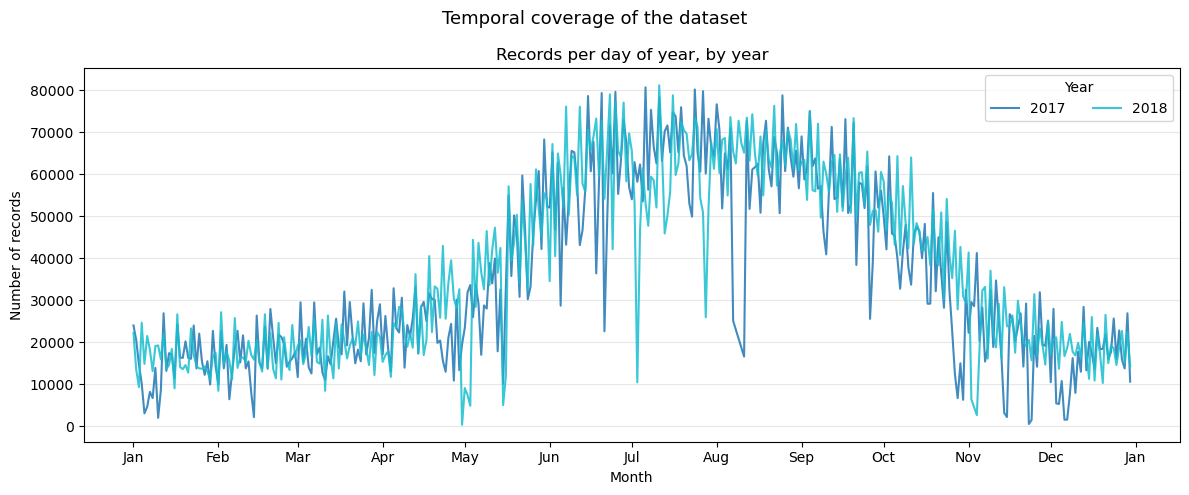

In [30]:
temporal = (
    df.groupby(['year', 'day_of_year'])
      .size()
      .reset_index(name='count')
)

years  = sorted(temporal['year'].unique().astype(int))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(years)))

# Map each day_of_year to a date in a fixed reference year so the
# x-axis can display month names while all series share the same range.

fig, ax = plt.subplots(figsize=(12, 5))

for year, color in zip(years, colors):
    subset = temporal[temporal['year'] == year].sort_values('day_of_year')
    dates = pd.to_datetime(
        subset['day_of_year'].astype(int).apply(lambda d: f'{REF_YEAR}-{d:03d}'),
        format='%Y-%j',
    )
    ax.plot(dates, subset['count'], label=str(year),
            color=color, alpha=0.85, linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlabel('Month')
ax.set_ylabel('Number of records')
ax.set_title('Records per day of year, by year')
ax.legend(title='Year', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal coverage of the dataset', fontsize=13)
plt.tight_layout()
plt.show()

Record counts are substantially higher during May–November compared with December–April, with a consistent seasonal pattern across both years. This is most likely driven by the GLWD land mask: at high latitudes (which contribute many pixels) winter snow and ice cause LPDR retrievals to fail the quality filters, reducing the number of valid pixels in the dataset. This seasonal bias should be considered when evaluating model performance across months.

### 2.2 Geographical distribution

The total number of observations accumulated per 0.25° grid cell across all days is mapped globally. Ideally coverage would be uniform; any systematically under-sampled region indicates where the model will have less training signal.

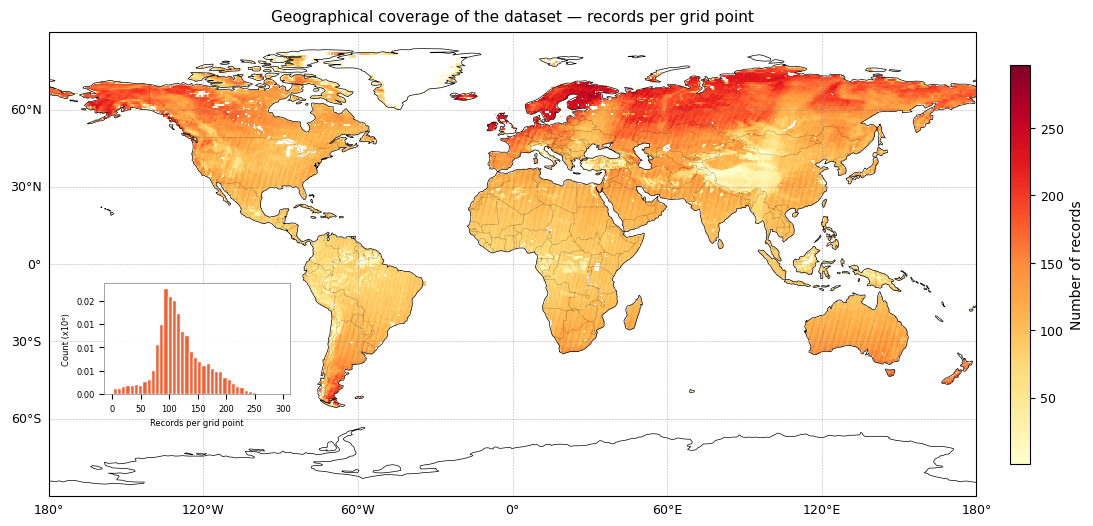

In [51]:
# ── 1. Compute records per location ─────────────────────────────────────────
records_per_loc = (
    df.groupby(['latitude_grid', 'longitude_grid'])
    .size()
    .reset_index(name='count')
)

# ── 2. Remap longitudes [0, 360] → [−180, 180] ──────────────────────────────
records_per_loc['longitude_grid'] = (
    (records_per_loc['longitude_grid'] + 180) % 360
) - 180

# ── 3. Pivot to 2-D grid ─────────────────────────────────────────────────────
pivot_count = records_per_loc.pivot(
    index='latitude_grid',
    columns='longitude_grid',
    values='count'
)

lats = pivot_count.index.values
lons = pivot_count.columns.values
data = pivot_count.values

# ── Helper: add inset histogram to bottom-left of a Cartopy axis ─────────────
# Position: [x0, y0, width, height] in axes-fraction coords (0–1).
#   x0, y0  — left/bottom corner of the inset box
#   width, height — size relative to the parent axes
# Increase x0 to shift right; increase y0 to shift up.
_INSET_POS   = [0.06, 0.22, 0.20, 0.24]
_INSET_COLOR = plt.cm.YlOrRd(0.6)   # orange sampled from the map colormap

def _map_inset_hist(ax, values, xlabel):
    ax_in = ax.inset_axes(_INSET_POS)
    ax_in.hist(values, bins=40, color=_INSET_COLOR, edgecolor='white')
    ax_in.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}')
    )
    ax_in.set_xlabel(xlabel, fontsize=6)
    ax_in.set_ylabel('Count (x10⁶)', fontsize=6)
    ax_in.tick_params(labelsize=6)
    ax_in.set_facecolor('white')
    ax_in.patch.set_alpha(0.85)
    for spine in ax_in.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(0.5)

# ── 4. Plot with Cartopy ─────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    lons, lats, data,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

_map_inset_hist(ax, records_per_loc['count'], 'Records per grid point')

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Number of records", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Geographical coverage of the dataset — records per grid point",
             fontsize=11, pad=8)

plt.tight_layout()
plt.show()

cnt = records_per_loc['count']

Pixel density increases markedly at high latitudes. This is a geometric artefact of the equal-angle 0.25° grid: grid cells shrink in physical area towards the poles, but the WindSat swath revisits them more frequently. The LPDR land mask also extends to higher latitudes in the Northern Hemisphere, adding more land pixels there. This spatial imbalance means that high-latitude grid cells are over-represented in the dataset relative to their physical area and may disproportionately influence the trained model.

## 3. Univariate Analysis

The marginal distribution of each variable is examined individually to detect skewness, outliers, and scale differences, and to evaluate appropriate transformations for the target variable.

### 3.1 Target variable — surface water fraction (`fwns`)

`fwns` is the primary target variable: the non-smoothed fractional open-water coverage at each pixel as retrieved by the LPDR algorithm. We examine its full distribution, the proportion of zero values (fully dry pixels), and the effect of several monotonic transformations aimed at reducing the strong right skew.

Total zeros: 8,683,427  (32.79% of all observations)


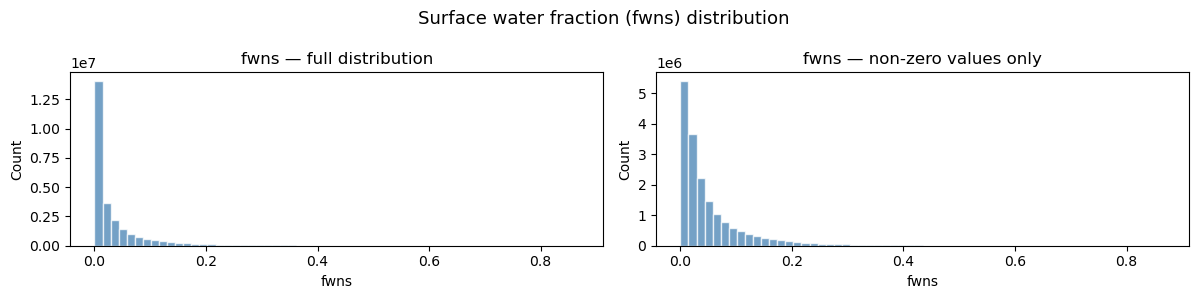

In [32]:
# Zero value analysis
n_zeros = (df['fwns'] == 0).sum()
pct_zeros = n_zeros / len(df) * 100
print(f"Total zeros: {n_zeros:,}  ({pct_zeros:.2f}% of all observations)")

# Distribution plot — full and non-zero side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(df['fwns'], bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_title('fwns — full distribution')
axes[0].set_xlabel('fwns')
axes[0].set_ylabel('Count')

x_pos = df['fwns'][df['fwns'] > 0]
axes[1].hist(x_pos, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].set_title('fwns — non-zero values only')
axes[1].set_xlabel('fwns')
axes[1].set_ylabel('Count')

plt.suptitle('Surface water fraction (fwns) distribution', fontsize=13)
plt.tight_layout()
plt.show()

A large majority of pixels have `fwns = 0` (fully dry land). Among non-zero values the distribution is strongly right-skewed, with a long tail extending to ~0.87. Regression models that assume or perform better with normally distributed targets will therefore benefit from a variance-stabilising transformation. Four candidates are evaluated on the non-zero subset.

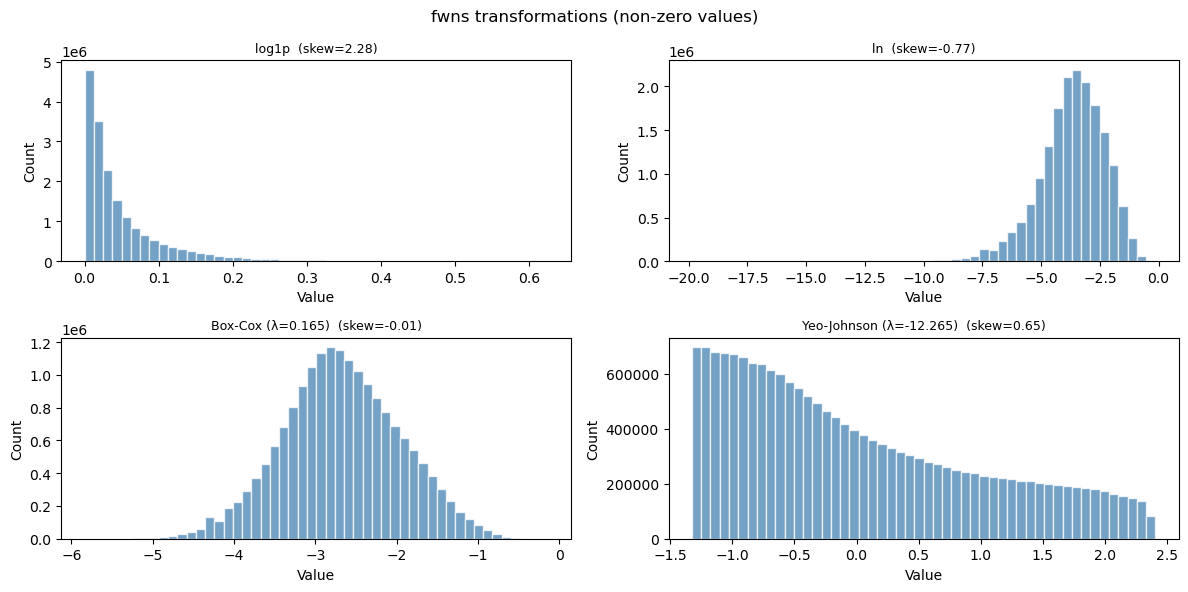

In [33]:
x_pos = df['fwns'][df['fwns'] > 0]

x_log1p  = np.log1p(x_pos)
x_ln     = x_pos.apply(np.log)
x_boxcox, lam_bc = stats.boxcox(x_pos)
pt = PowerTransformer(method='yeo-johnson')
x_yj = pt.fit_transform(x_pos.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

plots = [
    (axes[0], x_log1p,  f'log1p  (skew={stats.skew(x_log1p):.2f})'),
    (axes[1], x_ln,     f'ln  (skew={stats.skew(x_ln):.2f})'),
    (axes[2], x_boxcox, f'Box-Cox (λ={lam_bc:.3f})  (skew={stats.skew(x_boxcox):.2f})'),
    (axes[3], x_yj,     f'Yeo-Johnson (λ={pt.lambdas_[0]:.3f})  (skew={stats.skew(x_yj):.2f})'),
]
for ax, data, title in plots:
    ax.hist(data, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

fig.suptitle('fwns transformations (non-zero values)', fontsize=12)
plt.tight_layout()
plt.show()

Box-Cox achieves the lowest residual skew among the four candidates and produces the most symmetric distribution for non-zero values. It is therefore the preferred transformation for the target variable in subsequent modelling. Note that Box-Cox requires strictly positive input; the zero-inflation must be handled separately (e.g. via a two-stage model or by adding a small offset before transformation).

### 3.2 Brightness temperature variables

The WindSat brightness-temperature block consists of four physical quantities — `tbtoa` (top-of-atmosphere brightness temperature), `tran` (atmospheric transmittance), `tbdw` (downwelling atmospheric emission), and `tbup` (upwelling atmospheric emission) — each available at 19 GHz and 37 GHz in both V and H polarisations (16 columns total). Their marginal distributions are plotted with all four channels overlaid per variable to facilitate direct comparison.

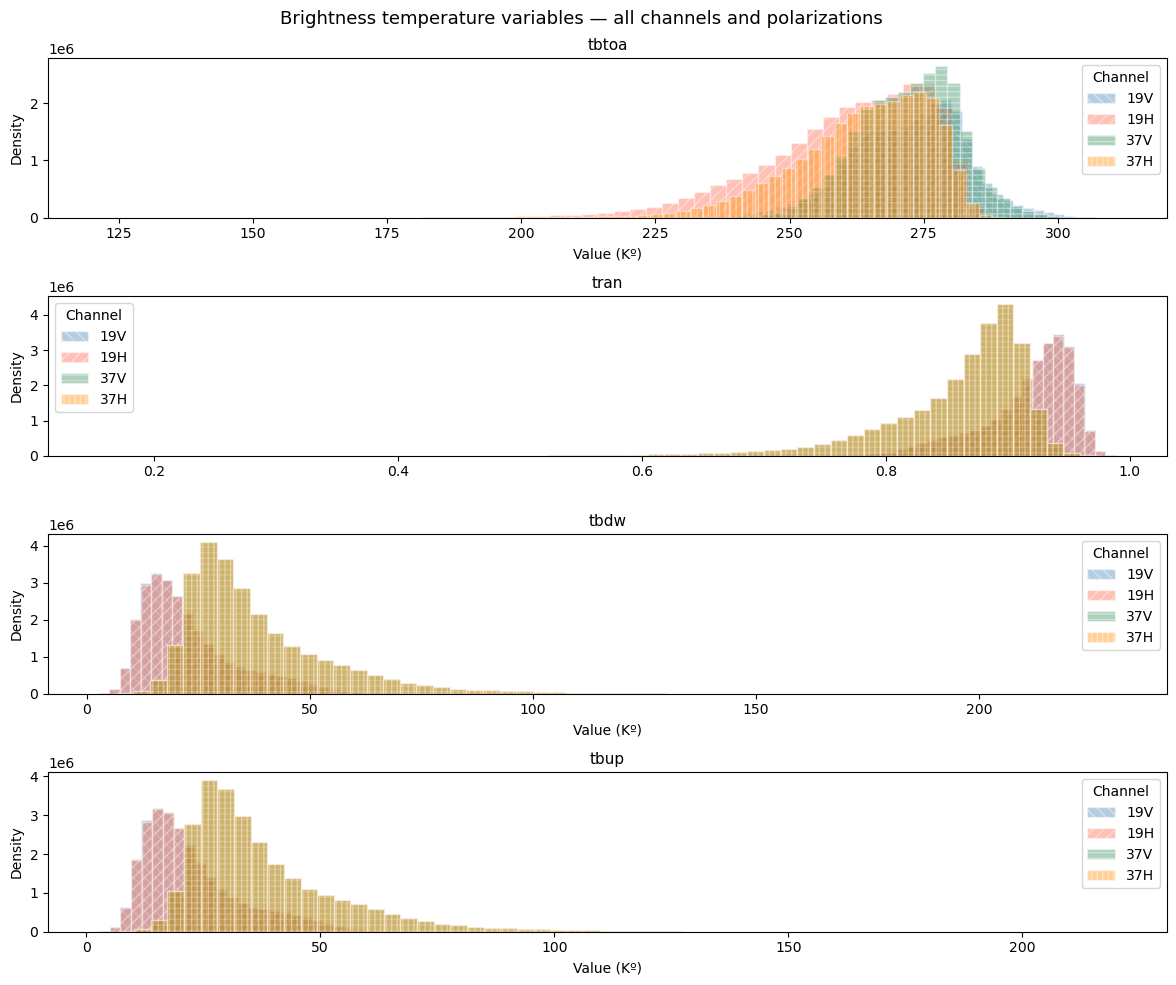

In [34]:
bt_vars = {
    'tbtoa': ['tbtoa19V', 'tbtoa19H', 'tbtoa37V', 'tbtoa37H'],
    'tran':  ['tran19V',  'tran19H',  'tran37V',  'tran37H'],
    'tbdw':  ['tbdw19V',  'tbdw19H',  'tbdw37V',  'tbdw37H'],
    'tbup':  ['tbup19V',  'tbup19H',  'tbup37V',  'tbup37H'],
}
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']
hatches = ['\\\\\\', '///', '---', '|||']
labels  = ['19V', '19H', '37V', '37H']

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for ax, (var_name, cols) in zip(axes, bt_vars.items()):
    for col, color, hatch, label in zip(cols, colors, hatches, labels):
        ax.hist(df[col].dropna(), bins=60, alpha=0.4, color=color,
                hatch=hatch, edgecolor='white', label=label)
    ax.set_title(var_name, fontsize=11)
    if var_name != 'tran':
        ax.set_xlabel('Value (Kº)')
    ax.set_ylabel('Density')
    ax.legend(title='Channel')

plt.suptitle('Brightness temperature variables — all channels and polarizations',
             fontsize=13)
plt.tight_layout()
plt.show()

Several structural patterns are apparent:

- **`tran`, `tbdw`, and `tbup`**: within each frequency band, the V and H polarisation channels are virtually identical, suggesting that polarisation carries no additional information for these atmospheric quantities. Furthermore, the distributions of `tbdw` and `tbup` are near-identical across channels, and `tran` appears to be a simple linear rescaling of the same underlying atmospheric opacity. This strong inter-variable redundancy is quantified in Section 4.1.
- **`tbtoa`**: the top-of-atmosphere brightness temperature does not exhibit this redundancy — the 19 GHz and 37 GHz channels have clearly distinct distributions, and H- and V-polarisations diverge meaningfully at both frequencies. This variable carries genuine information that is not duplicated across channels.

### 3.3 Auxiliary predictor variables

The remaining predictor variables — ERA5 surface skin temperature (`surtep_ERA5`), volumetric soil moisture (`vsm`), vegetation optical depth (`VOD`), minimum daily surface temperature (`Tmn`), precipitable water vapour (`PWV`), and vapour pressure deficit (`VPD`) — are shown individually.

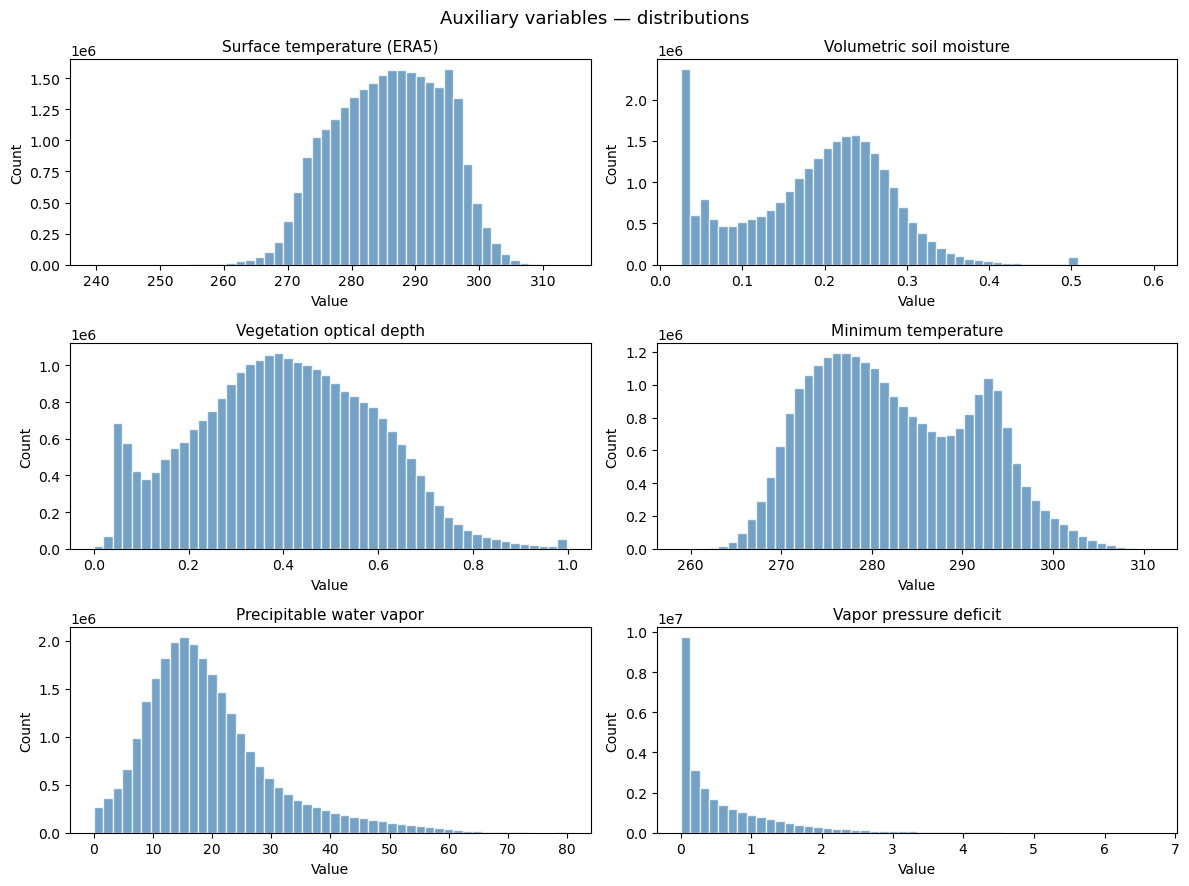

In [35]:
aux_vars = ['surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD']
aux_labels = {
    'surtep_ERA5': 'Surface temperature (ERA5)',
    'vsm':         'Volumetric soil moisture',
    'VOD':         'Vegetation optical depth',
    'Tmn':         'Minimum temperature',
    'PWV':         'Precipitable water vapor',
    'VPD':         'Vapor pressure deficit',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, var in zip(axes, aux_vars):
    ax.hist(df[var].dropna(), bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(aux_labels[var], fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Auxiliary variables — distributions', fontsize=13)
plt.tight_layout()
plt.show()

The auxiliary variables exhibit a variety of distribution shapes:

- **`surtep_ERA5`** and **`Tmn`**: broadly Gaussian, centred near ~285 K with a slight left tail from polar and alpine regions.
- **`vsm`**: roughly uniform in [0.025, 0.6], reflecting the diversity of land-surface moisture regimes across the globe.
- **`VOD`**: near-symmetric after normalisation to [0, 1], centred at ~0.39.
- **`PWV`**: right-skewed, with most land observations below 30 mm; the long tail corresponds to humid tropical regions.
- **`VPD`**: strongly right-skewed; the majority of observations cluster near zero (humid or cold conditions), with a sparse tail of high values in arid regions.

No variable shows values outside its physical range, confirming that the preprocessing filters were effective.

## 4. Multivariate Analysis

With 49 variables — many of which are derived from overlapping physical quantities — understanding inter-variable relationships is essential before feature selection. This section quantifies pairwise correlations within the brightness-temperature block, computes a full correlation matrix across the core predictor set, and assesses the effective dimensionality of the dataset via PCA.

### 4.1 Brightness temperature redundancy

The distributional overlap observed in Section 3.2 suggests that `tran`, `tbdw`, and `tbup` may be nearly collinear. To test this, the 12 atmospheric brightness-temperature columns are compared pairwise along three axes: same variable / different polarisation (V vs H), same variable / different frequency (19 vs 37 GHz), and same frequency / different physical variable (tbup vs tbdw vs atm, where `atm = (1 − tran) × 273.15` rescales transmittance to an approximate Kelvin range for direct numerical comparison).

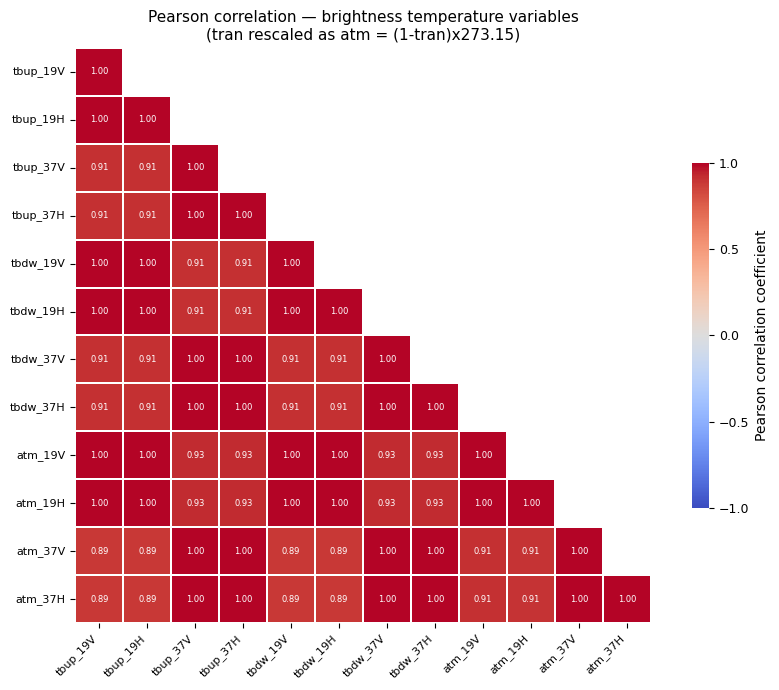

,Comparison type,Variable A,Variable B,r,R²,MAE,RMSE
0,Polarization (V vs H),tbup_19V,tbup_19H,1.0000,1.0000,0.2857,0.3271
1,Polarization (V vs H),tbup_37V,tbup_37H,1.0000,1.0000,0.0000,0.0000
2,Polarization (V vs H),tbdw_19V,tbdw_19H,1.0000,1.0000,0.2871,0.3290
3,Polarization (V vs H),tbdw_37V,tbdw_37H,1.0000,1.0000,0.0000,0.0000
4,Polarization (V vs H),atm_19V,atm_19H,1.0000,1.0000,0.2800,0.3181
5,Polarization (V vs H),atm_37V,atm_37H,1.0000,1.0000,0.0000,0.0000
6,Frequency (19 vs 37 GHz),tbup_19V,tbup_37V,0.9122,0.8321,15.3169,17.2720
7,Frequency (19 vs 37 GHz),tbup_19H,tbup_37H,0.9104,0.8288,15.0312,17.0010
8,Frequency (19 vs 37 GHz),tbdw_19V,tbdw_37V,0.9124,0.8325,15.4555,17.4367
9,Frequency (19 vs 37 GHz),tbdw_19H,tbdw_37H,0.9106,0.8291,15.1684,17.1640


In [36]:
# Rescale tran so it is comparable to tbup / tbdw (Kelvin range)
# (1 - tran) is atmospheric opacity; *100 puts it on a roughly similar scale
bt_cmp = pd.DataFrame({
    'tbup_19V': df['tbup19V'], 'tbup_19H': df['tbup19H'],
    'tbup_37V': df['tbup37V'], 'tbup_37H': df['tbup37H'],
    'tbdw_19V': df['tbdw19V'], 'tbdw_19H': df['tbdw19H'],
    'tbdw_37V': df['tbdw37V'], 'tbdw_37H': df['tbdw37H'],
    'atm_19V':  (1 - df['tran19V']) * 273.15,
    'atm_19H':  (1 - df['tran19H']) * 273.15,
    'atm_37V':  (1 - df['tran37V']) * 273.15,
    'atm_37H':  (1 - df['tran37H']) * 273.15,
}).dropna()

# ── 1. Correlation heatmap (lower triangle) ──────────────────────────────────
corr = bt_cmp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    ax=ax,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=True,
    fmt='.2f',
    annot_kws={"size": 6},
    linewidths=0.3,
    linecolor="white",
    mask=mask,
    cbar_kws={"shrink": 0.6, "label": "Pearson correlation coefficient", "orientation": "vertical"},
)
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.index, rotation=0, fontsize=8)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Pearson correlation coefficient", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
ax.set_title(
    'Pearson correlation — brightness temperature variables\n'
    '(tran rescaled as atm = (1-tran)x273.15)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── 2. Structured pair-comparison table ──────────────────────────────────────
def pair_stats(col_a, col_b):
    a, b = bt_cmp[col_a].values, bt_cmp[col_b].values
    r, _ = stats.pearsonr(a, b)
    mae  = np.mean(np.abs(a - b))
    rmse = np.sqrt(np.mean((a - b) ** 2))
    return r, r ** 2, mae, rmse

pair_groups = {
    # Same variable & frequency, different polarization (V vs H)
    'Polarization (V vs H)': [
        ('tbup_19V', 'tbup_19H'), ('tbup_37V', 'tbup_37H'),
        ('tbdw_19V', 'tbdw_19H'), ('tbdw_37V', 'tbdw_37H'),
        ('atm_19V',  'atm_19H'),  ('atm_37V',  'atm_37H'),
    ],
    # Same variable & polarization, different frequency (19 vs 37 GHz)
    'Frequency (19 vs 37 GHz)': [
        ('tbup_19V', 'tbup_37V'), ('tbup_19H', 'tbup_37H'),
        ('tbdw_19V', 'tbdw_37V'), ('tbdw_19H', 'tbdw_37H'),
        ('atm_19V',  'atm_37V'),  ('atm_19H',  'atm_37H'),
    ],
    # Same frequency & polarization, different physical variable (tbup vs tbdw vs atm)
    'Variable (tbup / tbdw / atm)': [
        ('tbup_19V', 'tbdw_19V'), ('tbup_19V', 'atm_19V'), ('tbdw_19V', 'atm_19V'),
        ('tbup_19H', 'tbdw_19H'), ('tbup_19H', 'atm_19H'), ('tbdw_19H', 'atm_19H'),
        ('tbup_37V', 'tbdw_37V'), ('tbup_37V', 'atm_37V'), ('tbdw_37V', 'atm_37V'),
        ('tbup_37H', 'tbdw_37H'), ('tbup_37H', 'atm_37H'), ('tbdw_37H', 'atm_37H'),
    ],
}

rows = []
for group, pairs in pair_groups.items():
    for col_a, col_b in pairs:
        r, r2, mae, rmse = pair_stats(col_a, col_b)
        rows.append({
            'Comparison type': group,
            'Variable A': col_a, 'Variable B': col_b,
            'r': round(r, 4), 'R²': round(r2, 4),
            'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
        })

tbl = pd.DataFrame(rows)

# Colour-code R² to make near-duplicates stand out
tbl.style \
    .background_gradient(subset=['r', 'R²'], cmap='RdYlGn', vmin=0, vmax=1) \
    .background_gradient(subset=['MAE', 'RMSE'], cmap='RdYlGn_r') \
    .format({'r': '{:.4f}', 'R²': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}'})

The correlation analysis reveals three important findings:

1. **Polarisation is redundant for atmospheric variables.** `tbup`, `tbdw`, and `atm` are near-perfectly correlated between V and H channels at both frequencies (r > 0.999). Retaining both polarisations for these variables provides no additional information and doubles the column count unnecessarily.
2. **Frequency provides meaningful discrimination.** Correlations between 19 GHz and 37 GHz channels are high but not perfect (r ≈ 0.96–0.98), so frequency-specific channels should be retained.
3. **`tbup` and `tbdw` are nearly identical.** MAE and RMSE between them are very small relative to their absolute values, and r² > 0.999 in all channels. Together with the transmittance-derived `atm`, all three variables encode essentially the same atmospheric state. One of the three (most likely `tbup`, since it is the upwelling term that directly enters the atmospheric correction) can serve as a proxy for all three with minimal information loss.

### 4.2 Full correlation matrix

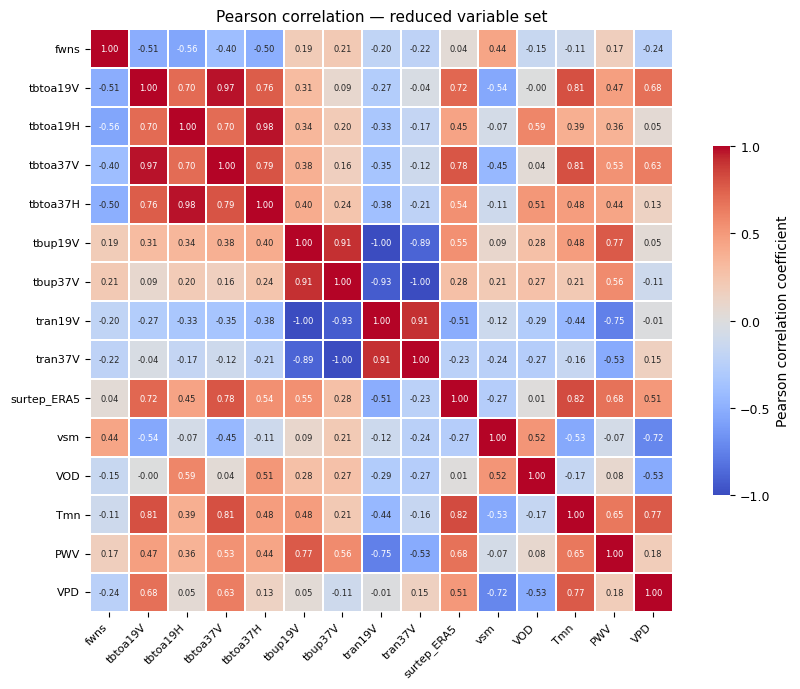

In [43]:
df_corr = df[['fwns', 'tbtoa19V', 'tbtoa19H', 'tbtoa37V', 'tbtoa37H', 'tbup19V', 'tbup37V', 'tran19V', 'tran37V', 'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD']]

corr = df_corr.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "shrink": 0.6,
        "label": "Pearson correlation coefficient",
        "orientation": "vertical",
    },
)

ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, rotation=0, fontsize=8)
ax.set_title(
    'Pearson correlation — reduced variable set',
    fontsize=11,
)

# Style the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Pearson correlation coefficient", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

plt.tight_layout()
plt.show()

The full Pearson correlation matrix (computed over the core predictor set, excluding derived, encoded, and categorical columns) reveals several noteworthy relationships:

- **`tbtoa` channels** are strongly correlated with each other across frequencies and polarisations (r > 0.85), as expected from the shared physical source.
- **`tbtoa` vs `fwns`**: a strong negative correlation (r ≈ −0.6) is observed between surface brightness temperature and LPDR surface water fraction. This is physically meaningful: wetter surfaces have lower emissivity and thus lower brightness temperatures.
- **`ref_land_emis_de_lannoy_K_h` vs `VOD`**: moderate positive correlation (r ≈ 0.5), consistent with the De Lannoy et al. (2016) LUT design, where denser vegetation (higher VOD) maps to higher reference land emissivity.
- **`Tmn` vs `tbtoa`**: strong positive correlation, as thermal emission scales with surface temperature.
- **`Tmn` vs `VPD`**: positive correlation reflecting the physical link between higher temperatures and larger vapour pressure deficits.

## 5. Machine Learning Considerations

The preceding analysis highlights several structural properties of the dataset that have direct implications for model development.

### 5.1 Feature scaling

In [38]:
df.max() - df.min()

latitude_grid                  138.000000
longitude_grid                 359.750000
surtep_ERA5                     74.037567
fwns                             0.868315
Tmn                             52.225739
PWV                             80.000000
VOD                              0.998577
vsm                              0.575000
VPD                              6.695256
quality_flag                   192.000000
ref_land_emis_de_lannoy_K_h      0.184196
ref_land_emis_de_lannoy_K_v      0.111272
tbtoa19V                       115.000000
tbtoa19H                       179.835007
tbtoa37V                       139.100006
tbtoa37H                       146.952499
tran19V                          0.512537
tran19H                          0.515374
tran37V                          0.818457
tran37H                          0.818457
tbdw19V                        139.333755
tbdw19H                        140.149094
tbdw37V                        223.943954
tbdw37H                        223

The feature ranges span several orders of magnitude: `fwns` varies over [0, 0.87], while `tbtoa` values reach up to ~300 K and `day_of_year` runs to 365. Distance- and gradient-based models (neural networks, SVMs, k-NN) are sensitive to these scale differences. **Standardisation (zero mean, unit variance) is required** before training any such model. Tree-based models (random forests, gradient boosting) are scale-invariant and can be trained directly on the raw features.

Note that `year` has a range of only 1 (2017 vs 2018); it carries negligible variance and may be dropped or replaced by the cyclic `doy_sin`/`doy_cos` encodings already present in the dataset.

### 5.2 Dimensionality study

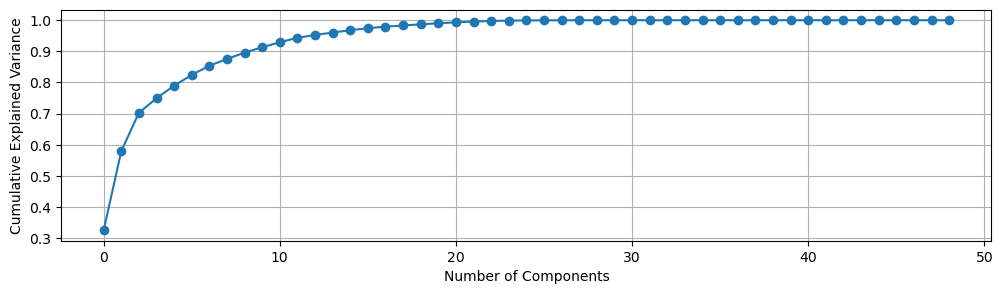

In [39]:
numeric_df = df.select_dtypes(include='number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(12,3))
plt.plot(cumulative, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

Approximately **20 principal components** are needed to explain 95% of the total variance, despite the dataset having 49 columns. This confirms the high degree of redundancy identified in Section 4.1 (near-duplicate polarisation channels, correlated atmospheric variables) and suggests that aggressive feature selection or dimensionality reduction is warranted before training. The practical implication is that a model trained on 20 carefully selected or derived features is likely to generalise as well as one trained on the full 49-column set, while being faster to train and easier to interpret.

## 6. Spatial and Temporal Structure of the Target Variable

Each observation corresponds to a specific (latitude, longitude) grid cell and calendar day. Understanding how the target variable `fwns` varies across both dimensions informs the choice of train/test split strategy, helps identify seasonally or geographically biased training sets, and motivates the cyclic temporal and spatial encodings already present in the dataset.

### 6.1 Temporal statistics per grid cell

For each 0.25° grid cell the temporal mean and standard deviation of `fwns` across all available days are computed and mapped globally. High temporal variance in a cell indicates strong seasonal dynamics (e.g. floodplains, seasonal wetlands, monsoon-influenced regions), while low variance indicates stable conditions.

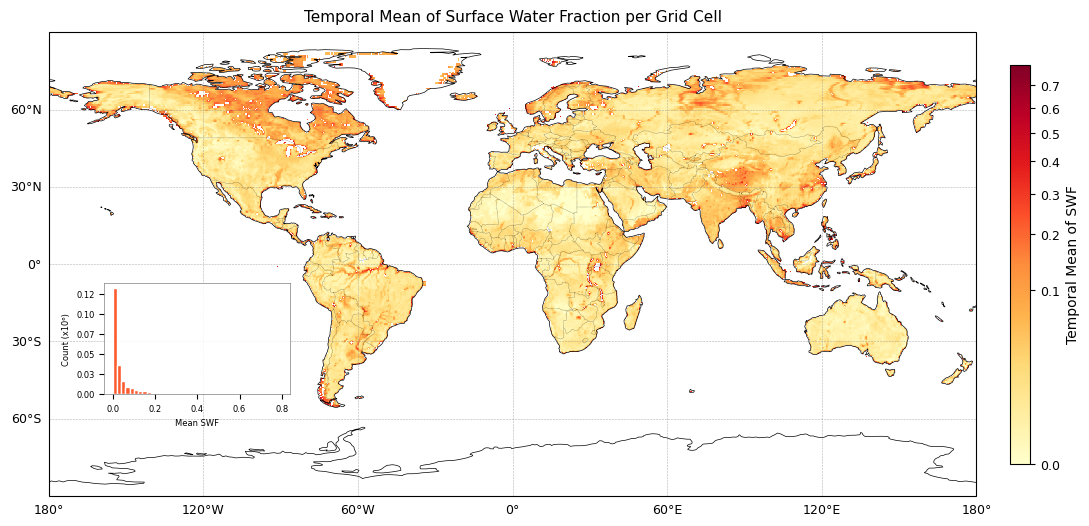

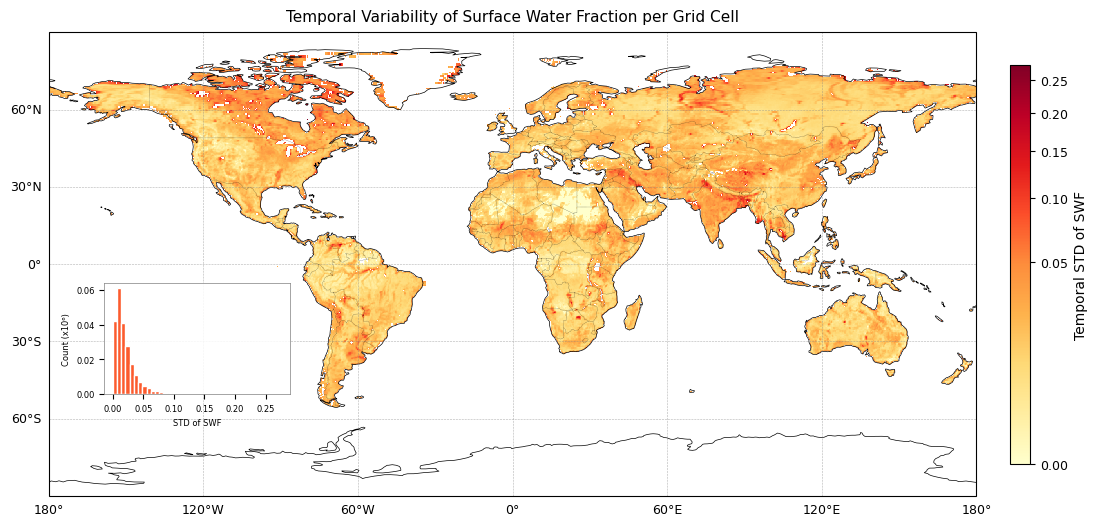

In [52]:
# ── 1. Compute temporal stats ────────────────────────────────────────────────
temporal_stats = (
    df.groupby(["latitude_grid", "longitude_grid"])["fwns"]
    .agg(["mean", "std", "var", "count"])
    .reset_index()
)
temporal_stats["cv"] = temporal_stats["std"] / temporal_stats["mean"]

# ── 2. Remap longitudes from [0, 360] → [−180, 180] ─────────────────────────
temporal_stats["longitude_grid"] = (
    (temporal_stats["longitude_grid"] + 180) % 360
) - 180

# ── 3. Pivot to 2-D grid (rows = lat, cols = lon) ───────────────────────────
pivot_mean = temporal_stats.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="mean"
)

lats_mean = pivot_mean.index.values
lons_mean = pivot_mean.columns.values
data_mean = pivot_mean.values

pivot_std = temporal_stats.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="std"
)

lats_std = pivot_std.index.values
lons_std = pivot_std.columns.values
data_std = pivot_std.values

# ── 4. Temporal mean map ──────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

norm_mean = PowerNorm(gamma=0.4, vmin=0, vmax=float(np.nanmax(data_mean)))
mesh = ax.pcolormesh(
    lons_mean, lats_mean, data_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    norm=norm_mean,
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

_map_inset_hist(ax, temporal_stats['mean'].dropna(), 'Mean SWF')

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Temporal Mean of SWF", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Temporal Mean of Surface Water Fraction per Grid Cell",
             fontsize=11, pad=8)

plt.tight_layout()

# ── 5. Temporal STD map ───────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

norm_std = PowerNorm(gamma=0.4, vmin=0, vmax=float(np.nanmax(data_std)))
mesh = ax.pcolormesh(
    lons_std, lats_std, data_std,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    norm=norm_std,
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                  alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

ax.set_global()

_map_inset_hist(ax, temporal_stats['std'].dropna(), 'STD of SWF')

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.03)
cbar.set_label("Temporal STD of SWF", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Temporal Variability of Surface Water Fraction per Grid Cell",
             fontsize=11, pad=8)

plt.tight_layout()
plt.show()

### 6.2 Daily spatial statistics

The spatial mean and standard deviation of `fwns` across all valid land pixels are computed for each day in both years and plotted as time series. This reveals how the global average wetness and its spread change throughout the year.

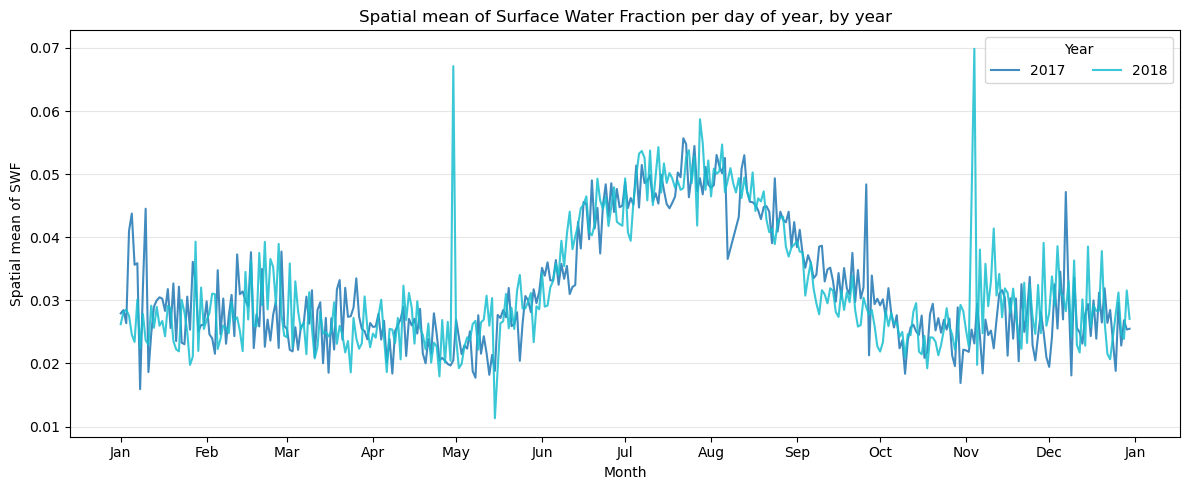

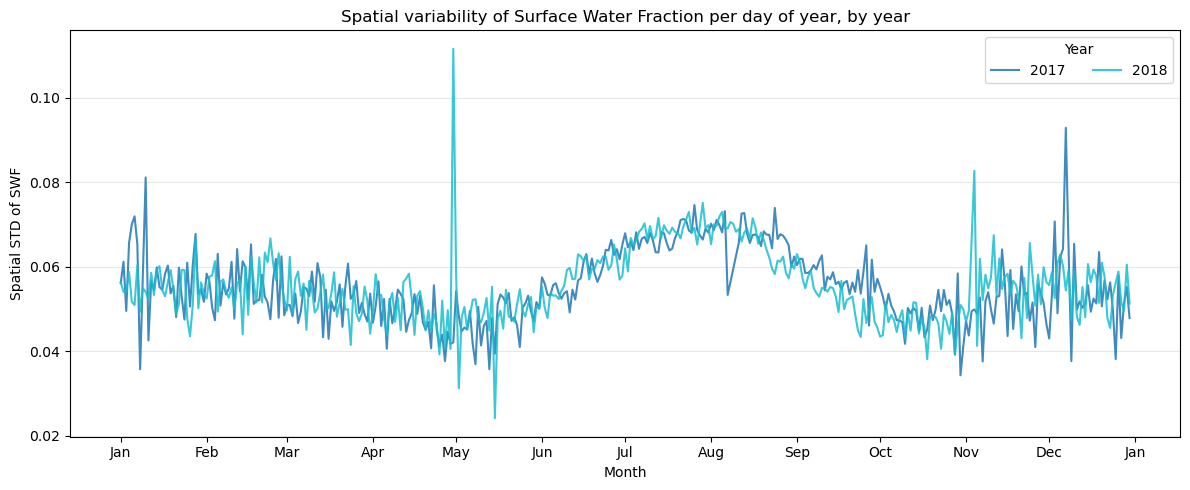

In [42]:
# ── 1. Compute spatial stats grouped by year + day_of_year ──────────────────
spatial_stats = (
    df.groupby(['year', 'day_of_year'])['fwns']
    .agg(['mean', 'std'])
    .reset_index()
)

years  = sorted(spatial_stats['year'].unique().astype(int))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(years)))

# ── 2. Helper to avoid code duplication ─────────────────────────────────────
def plot_spatial_stat(metric, ylabel, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    for year, color in zip(years, colors):
        subset = spatial_stats[spatial_stats['year'] == year].sort_values('day_of_year')
        dates  = pd.to_datetime(
            subset['day_of_year'].astype(int).apply(lambda d: f'{REF_YEAR}-{d:03d}'),
            format='%Y-%j',
        )
        ax.plot(dates, subset[metric], label=str(year),
                color=color, alpha=0.85, linewidth=1.5)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Year', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── 3. Mean plot ─────────────────────────────────────────────────────────────
plot_spatial_stat(
    metric   = 'mean',
    ylabel   = 'Spatial mean of SWF',
    title    = 'Spatial mean of Surface Water Fraction per day of year, by year',
)

# ── 4. STD plot ──────────────────────────────────────────────────────────────
plot_spatial_stat(
    metric   = 'std',
    ylabel   = 'Spatial STD of SWF',
    title    = 'Spatial variability of Surface Water Fraction per day of year, by year',
)